# 🧹 Denoising Autoencoder on MNIST
**Goal:** Train three autoencoder architectures to remove noise from MNIST digit images.

| Model | Architecture |
|---|---|
| Model 1 | Fully Connected (FFNN) Autoencoder |
| Model 2 | Convolutional + Transpose Conv Autoencoder |
| Model 3 | Convolutional + Upsampling Autoencoder |

We add **Gaussian noise** to the input, and train each model to reconstruct the **clean** original.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim as optim

from torchvision import datasets, transforms

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {DEVICE}")

PyTorch version : 2.11.0+cu128
GPU available   : True
Using device    : cuda


## 2. Hyperparameters

In [2]:
BATCH_SIZE  = 20
VALID_SPLIT = 0.2
EPOCHS      = 20
LR          = 0.001          # Adam lr  (0.001 is more stable than 0.01)
NOISE_FACTOR = 0.4           # how much Gaussian noise to add (0 = no noise)
SEED        = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

## 3. Data Loading

In [3]:
transform = transforms.ToTensor()   # scales pixels to [0, 1]

train_data = datasets.MNIST('data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('data', train=False, download=True, transform=transform)

# ---- train / validation split ----
num_train = len(train_data)
indices   = list(range(num_train))
np.random.shuffle(indices)

split       = int(np.floor(VALID_SPLIT * num_train))
train_idx   = indices[split:]
valid_idx   = indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0)
valid_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=valid_sampler, num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")
print(f"Test  batches : {len(test_loader)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 944kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]

Train batches : 2400
Valid batches : 600
Test  batches : 500


## 4. Visualise a Batch

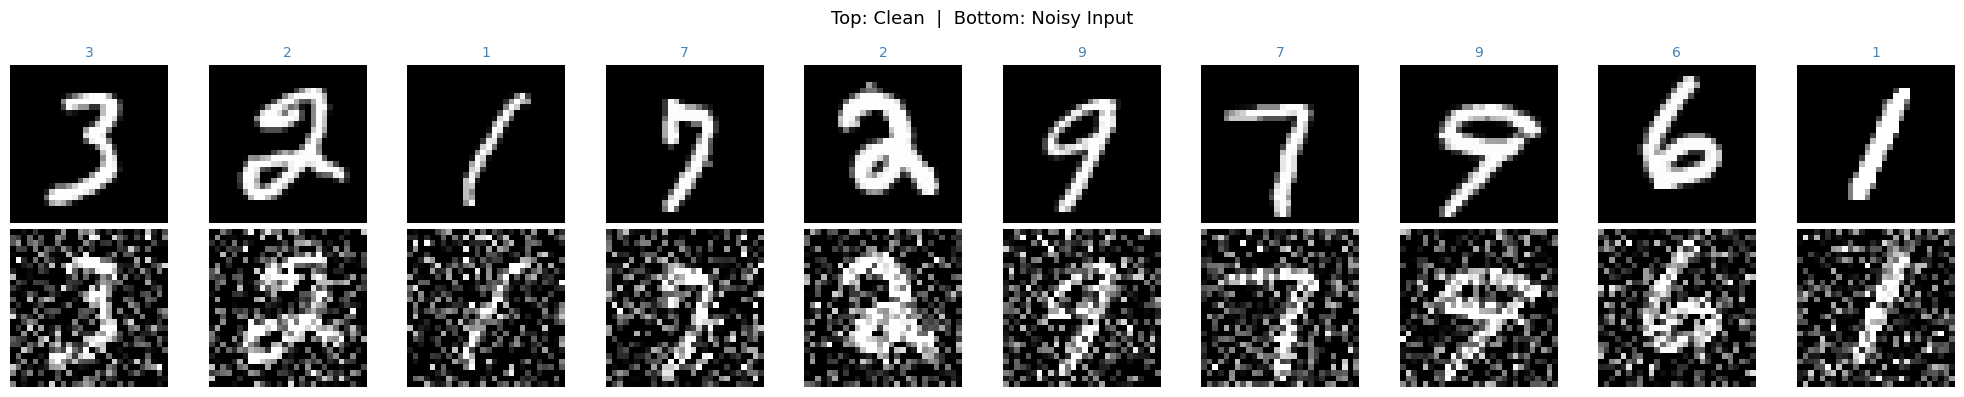

In [5]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(labels[i].item(), color='steelblue', fontsize=10)
    axes[0, i].axis('off')

    # show what the model will receive as input (noisy version)
    noisy = images[i] + NOISE_FACTOR * torch.randn_like(images[i])
    noisy = torch.clamp(noisy, 0., 1.)
    axes[1, i].imshow(noisy.squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Clean', fontsize=11)
axes[1, 0].set_ylabel('Noisy', fontsize=11)
plt.suptitle('Top: Clean  |  Bottom: Noisy Input', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Model Architectures

All three models:
- **Input:** noisy image
- **Output:** reconstructed clean image
- **Loss:** MSE vs. clean image

In [6]:
# Model 1 : Fully Connected (FFNN) Autoencoder

class FFNNAutoencoder(nn.Module):
    """Simple linear encoder → linear decoder with a 32-dim bottleneck."""
    def __init__(self, bottleneck_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, bottleneck_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(x.size(0), 1, 28, 28)
        return x

# Model 2 : Convolutional Autoencoder (Transpose Conv)

class TransposeConvAutoencoder(nn.Module):
    """
    Encoder: Conv → Pool → Conv → Pool  (28→14→7)
    Decoder: ConvTranspose → ConvTranspose  (7→14→28)
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 4, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Decoder
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(4, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.dec(self.enc(x))


# Model 3 : Convolutional Autoencoder (Upsampling)

class UpsampleConvAutoencoder(nn.Module):
    """
    Same encoder as Model 2.
    Decoder uses nn.Upsample (no checkerboard artefacts) instead of
    ConvTranspose2d, followed by regular Conv2d layers.
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 4, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Decoder  — nn.Upsample replaces the deprecated F.upsample
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(4, 16, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.dec(self.enc(x))


# ── Instantiate and move to GPU / CPU ──
model_1 = FFNNAutoencoder(bottleneck_dim=32).to(DEVICE)
model_2 = TransposeConvAutoencoder().to(DEVICE)
model_3 = UpsampleConvAutoencoder().to(DEVICE)

for name, m in [('FFNN', model_1), ('Transpose CNN', model_2), ('Upsample CNN', model_3)]:
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:20s} → {params:,} trainable parameters")

FFNN                 → 419,120 trainable parameters
Transpose CNN        → 1,077 trainable parameters
Upsample CNN         → 1,477 trainable parameters


## 6. Noise Helper

In [7]:
def add_noise(images, noise_factor=NOISE_FACTOR):
    """Add Gaussian noise and clamp to [0, 1]."""
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0., 1.)

## 7. Training & Validation Loop

In [8]:
criterion = nn.MSELoss()


def train_model(model, model_name, lr=LR, epochs=EPOCHS):
    """
    Trains a denoising autoencoder:
      - input  : noisy image
      - target : clean image
    Saves the best checkpoint (lowest validation loss).
    Returns dict with train/valid loss history.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = {'train': [], 'valid': []}
    best_loss = np.inf

    for epoch in range(1, epochs + 1):

        # ── Training
        model.train()
        running_train = 0.0
        for clean_imgs, _ in train_loader:
            clean_imgs  = clean_imgs.to(DEVICE)
            noisy_imgs  = add_noise(clean_imgs)

            optimizer.zero_grad()
            output = model(noisy_imgs)
            loss   = criterion(output, clean_imgs)
            loss.backward()
            optimizer.step()
            running_train += loss.item()

        # ── Validation
        model.eval()
        running_valid = 0.0
        with torch.no_grad():
            for clean_imgs, _ in valid_loader:
                clean_imgs = clean_imgs.to(DEVICE)
                noisy_imgs = add_noise(clean_imgs)
                output     = model(noisy_imgs)
                loss       = criterion(output, clean_imgs)
                running_valid += loss.item()

        # ── Epoch stats
        avg_train = running_train / len(train_loader)
        avg_valid = running_valid / len(valid_loader)
        history['train'].append(avg_train)
        history['valid'].append(avg_valid)

        improved = '  ✅ saved' if avg_valid < best_loss else ''
        print(f"Epoch {epoch:02d}/{epochs}  "
              f"Train Loss: {avg_train:.5f}  "
              f"Valid Loss: {avg_valid:.5f}{improved}")

        if avg_valid < best_loss:
            best_loss = avg_valid
            torch.save(model.state_dict(), f'{model_name}_best.pth')

    # Load best weights before returning
    model.load_state_dict(torch.load(f'{model_name}_best.pth', map_location=DEVICE))
    print(f"\nBest validation loss for {model_name}: {best_loss:.5f}\n")
    return history

### 7a. Train Model 1 — FFNN Autoencoder

In [9]:
print("=" * 60)
print("  Model 1 : FFNN Autoencoder")
print("=" * 60)
history_1 = train_model(model_1, 'FFNN')

  Model 1 : FFNN Autoencoder
Epoch 01/20  Train Loss: 0.03203  Valid Loss: 0.02228  ✅ saved
Epoch 02/20  Train Loss: 0.02039  Valid Loss: 0.01947  ✅ saved
Epoch 03/20  Train Loss: 0.01845  Valid Loss: 0.01795  ✅ saved
Epoch 04/20  Train Loss: 0.01743  Valid Loss: 0.01704  ✅ saved
Epoch 05/20  Train Loss: 0.01671  Valid Loss: 0.01647  ✅ saved
Epoch 06/20  Train Loss: 0.01623  Valid Loss: 0.01643  ✅ saved
Epoch 07/20  Train Loss: 0.01588  Valid Loss: 0.01601  ✅ saved
Epoch 08/20  Train Loss: 0.01558  Valid Loss: 0.01556  ✅ saved
Epoch 09/20  Train Loss: 0.01536  Valid Loss: 0.01549  ✅ saved
Epoch 10/20  Train Loss: 0.01518  Valid Loss: 0.01518  ✅ saved
Epoch 11/20  Train Loss: 0.01502  Valid Loss: 0.01522
Epoch 12/20  Train Loss: 0.01486  Valid Loss: 0.01493  ✅ saved
Epoch 13/20  Train Loss: 0.01475  Valid Loss: 0.01494
Epoch 14/20  Train Loss: 0.01462  Valid Loss: 0.01480  ✅ saved
Epoch 15/20  Train Loss: 0.01453  Valid Loss: 0.01471  ✅ saved
Epoch 16/20  Train Loss: 0.01444  Valid Loss

### 7b. Train Model 2 — Transpose Conv Autoencoder

In [10]:
print("=" * 60)
print("  Model 2 : Transpose Convolutional Autoencoder")
print("=" * 60)
history_2 = train_model(model_2, 'TransposeConv')

  Model 2 : Transpose Convolutional Autoencoder
Epoch 01/20  Train Loss: 0.03742  Valid Loss: 0.02143  ✅ saved
Epoch 02/20  Train Loss: 0.02029  Valid Loss: 0.01976  ✅ saved
Epoch 03/20  Train Loss: 0.01924  Valid Loss: 0.01901  ✅ saved
Epoch 04/20  Train Loss: 0.01881  Valid Loss: 0.01872  ✅ saved
Epoch 05/20  Train Loss: 0.01851  Valid Loss: 0.01845  ✅ saved
Epoch 06/20  Train Loss: 0.01831  Valid Loss: 0.01817  ✅ saved
Epoch 07/20  Train Loss: 0.01811  Valid Loss: 0.01809  ✅ saved
Epoch 08/20  Train Loss: 0.01800  Valid Loss: 0.01803  ✅ saved
Epoch 09/20  Train Loss: 0.01794  Valid Loss: 0.01818
Epoch 10/20  Train Loss: 0.01786  Valid Loss: 0.01785  ✅ saved
Epoch 11/20  Train Loss: 0.01783  Valid Loss: 0.01782  ✅ saved
Epoch 12/20  Train Loss: 0.01777  Valid Loss: 0.01767  ✅ saved
Epoch 13/20  Train Loss: 0.01775  Valid Loss: 0.01775
Epoch 14/20  Train Loss: 0.01769  Valid Loss: 0.01769
Epoch 15/20  Train Loss: 0.01768  Valid Loss: 0.01770
Epoch 16/20  Train Loss: 0.01766  Valid Los

### 7c. Train Model 3 — Upsampling Conv Autoencoder

In [11]:
print("=" * 60)
print("  Model 3 : Upsampling Convolutional Autoencoder")
print("=" * 60)
history_3 = train_model(model_3, 'UpsampleConv')

  Model 3 : Upsampling Convolutional Autoencoder
Epoch 01/20  Train Loss: 0.02591  Valid Loss: 0.01587  ✅ saved
Epoch 02/20  Train Loss: 0.01512  Valid Loss: 0.01462  ✅ saved
Epoch 03/20  Train Loss: 0.01423  Valid Loss: 0.01394  ✅ saved
Epoch 04/20  Train Loss: 0.01379  Valid Loss: 0.01359  ✅ saved
Epoch 05/20  Train Loss: 0.01353  Valid Loss: 0.01345  ✅ saved
Epoch 06/20  Train Loss: 0.01332  Valid Loss: 0.01325  ✅ saved
Epoch 07/20  Train Loss: 0.01316  Valid Loss: 0.01312  ✅ saved
Epoch 08/20  Train Loss: 0.01303  Valid Loss: 0.01324
Epoch 09/20  Train Loss: 0.01290  Valid Loss: 0.01295  ✅ saved
Epoch 10/20  Train Loss: 0.01281  Valid Loss: 0.01277  ✅ saved
Epoch 11/20  Train Loss: 0.01274  Valid Loss: 0.01269  ✅ saved
Epoch 12/20  Train Loss: 0.01267  Valid Loss: 0.01282
Epoch 13/20  Train Loss: 0.01265  Valid Loss: 0.01265  ✅ saved
Epoch 14/20  Train Loss: 0.01258  Valid Loss: 0.01264  ✅ saved
Epoch 15/20  Train Loss: 0.01253  Valid Loss: 0.01247  ✅ saved
Epoch 16/20  Train Loss:

## 8. Loss Curves

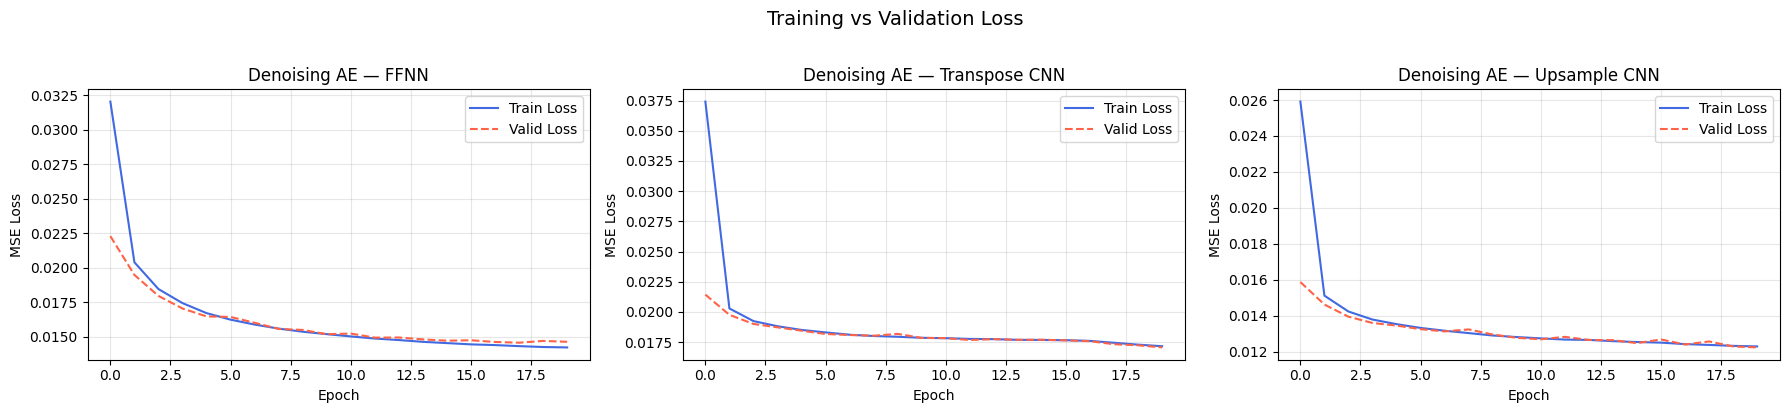

In [12]:
model_names   = ['FFNN', 'Transpose CNN', 'Upsample CNN']
all_histories = [history_1, history_2, history_3]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, name in zip(axes, all_histories, model_names):
    ax.plot(hist['train'], label='Train Loss', color='royalblue')
    ax.plot(hist['valid'], label='Valid Loss', color='tomato', linestyle='--')
    ax.set_title(f'Denoising AE — {name}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training vs Validation Loss', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Test — Visualise Denoising Results

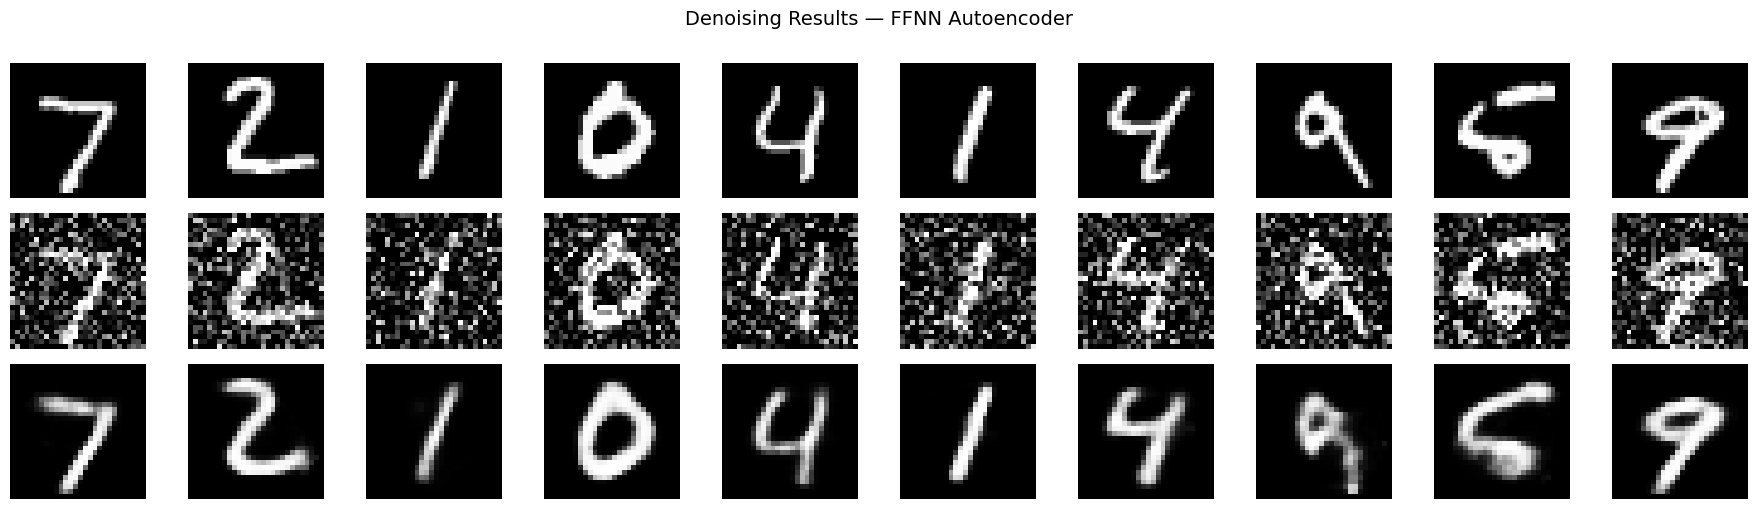

In [13]:
def visualise_denoising(model, model_name, n_images=10):
    """
    Plots three rows:
      Row 1 — Original clean images
      Row 2 — Noisy inputs
      Row 3 — Model reconstructions (denoised)
    """
    model.eval()
    dataiter    = iter(test_loader)
    clean_imgs, _ = next(dataiter)
    clean_imgs  = clean_imgs[:n_images].to(DEVICE)
    noisy_imgs  = add_noise(clean_imgs)

    with torch.no_grad():
        reconstructed = model(noisy_imgs)

    # Move everything to CPU for plotting
    clean_np  = clean_imgs.cpu().numpy()
    noisy_np  = noisy_imgs.cpu().numpy()
    recon_np  = reconstructed.cpu().numpy()

    fig, axes = plt.subplots(3, n_images, figsize=(18, 5))
    row_labels = ['Original', 'Noisy Input', 'Denoised']

    for col in range(n_images):
        for row, img_set in enumerate([clean_np, noisy_np, recon_np]):
            axes[row, col].imshow(img_set[col].squeeze(), cmap='gray')
            axes[row, col].axis('off')
        # Add row labels on the leftmost column
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11, labelpad=40, rotation=0, va='center')

    plt.suptitle(f'Denoising Results — {model_name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


visualise_denoising(model_1, 'FFNN Autoencoder')

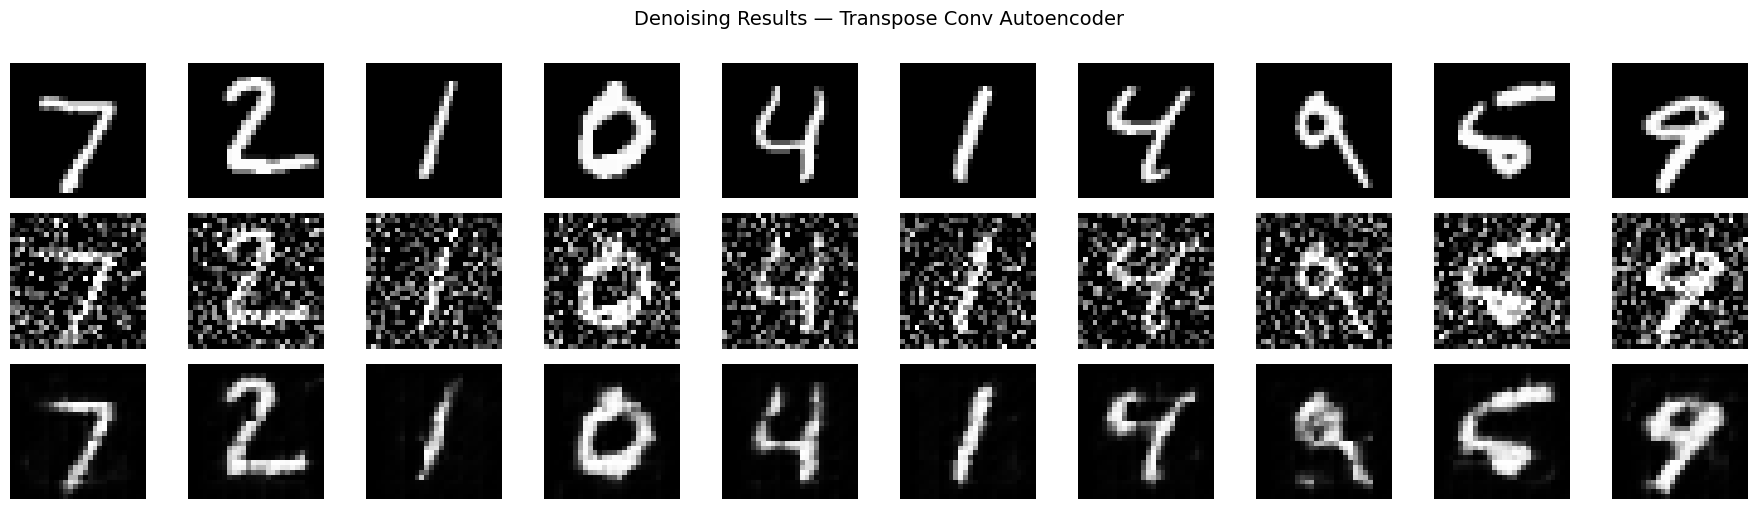

In [14]:
visualise_denoising(model_2, 'Transpose Conv Autoencoder')

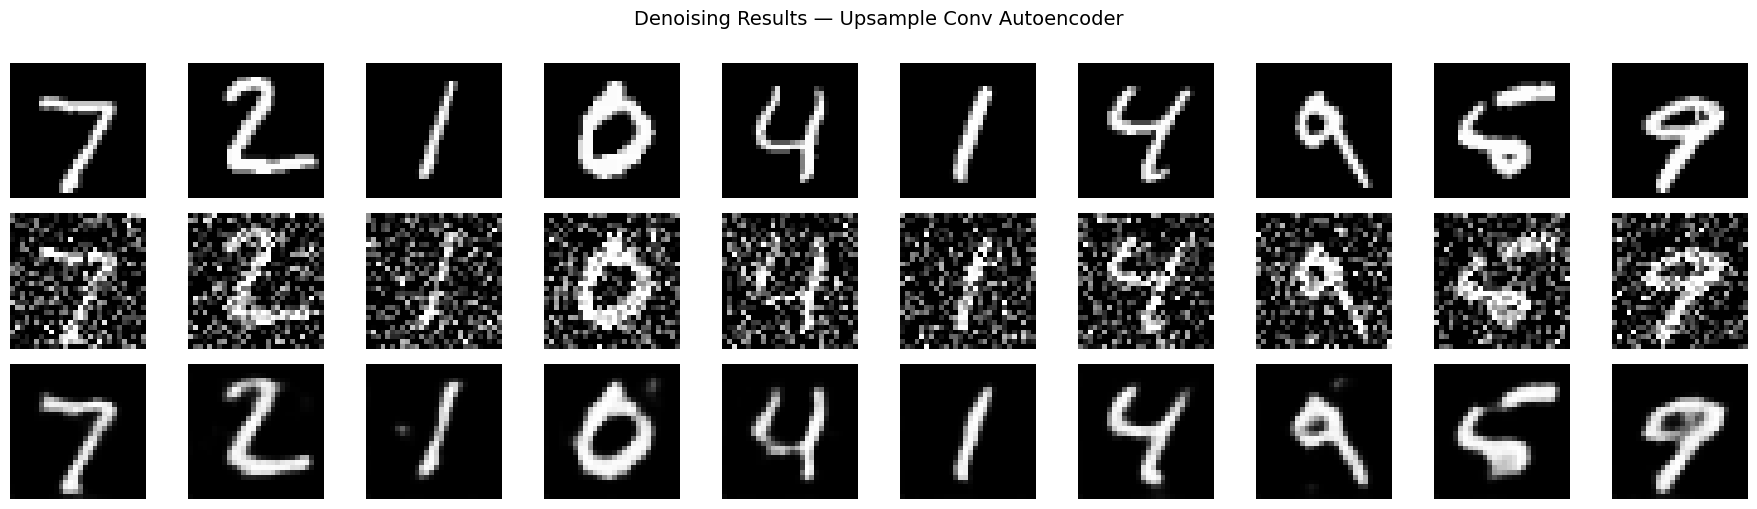

In [15]:
visualise_denoising(model_3, 'Upsample Conv Autoencoder')

## 10. Quantitative Comparison on Test Set

In [16]:
def evaluate_test_loss(model, model_name):
    """Compute average MSE on the full test set."""
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for clean_imgs, _ in test_loader:
            clean_imgs = clean_imgs.to(DEVICE)
            noisy_imgs = add_noise(clean_imgs)
            output     = model(noisy_imgs)
            total_loss += criterion(output, clean_imgs).item()
    avg_loss = total_loss / len(test_loader)
    print(f"{model_name:30s} | Test MSE: {avg_loss:.5f}")
    return avg_loss


print("─" * 55)
print(f"{'Model':30s} | {'Test MSE'}")
print("─" * 55)
l1 = evaluate_test_loss(model_1, 'FFNN Autoencoder')
l2 = evaluate_test_loss(model_2, 'Transpose Conv Autoencoder')
l3 = evaluate_test_loss(model_3, 'Upsample Conv Autoencoder')
print("─" * 55)

best_model = ['FFNN', 'Transpose Conv', 'Upsample Conv'][np.argmin([l1, l2, l3])]
print(f"\n🏆 Best model: {best_model} Autoencoder")

───────────────────────────────────────────────────────
Model                          | Test MSE
───────────────────────────────────────────────────────
FFNN Autoencoder               | Test MSE: 0.01421
Transpose Conv Autoencoder     | Test MSE: 0.01684
Upsample Conv Autoencoder      | Test MSE: 0.01202
───────────────────────────────────────────────────────

🏆 Best model: Upsample Conv Autoencoder


## 11. Vary Noise Level — Robustness Check

See how each model holds up as we increase the noise factor.

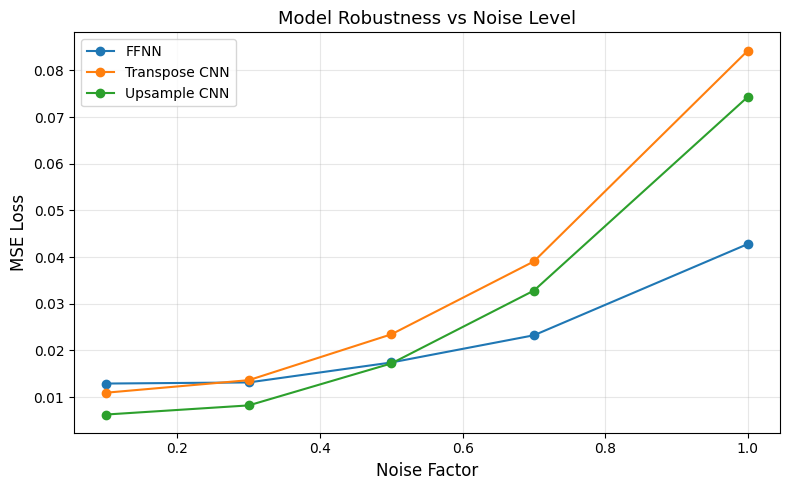

In [17]:
noise_levels = [0.1, 0.3, 0.5, 0.7, 1.0]
models_dict  = {
    'FFNN'         : model_1,
    'Transpose CNN': model_2,
    'Upsample CNN' : model_3
}

# One batch of clean test images (reused across all noise levels)
clean_batch, _ = next(iter(test_loader))
clean_batch    = clean_batch.to(DEVICE)

results = {name: [] for name in models_dict}

for nf in noise_levels:
    noisy = add_noise(clean_batch, noise_factor=nf)
    for name, model in models_dict.items():
        model.eval()
        with torch.no_grad():
            out  = model(noisy)
            loss = criterion(out, clean_batch).item()
        results[name].append(loss)

# Plot
plt.figure(figsize=(8, 5))
for name, losses in results.items():
    plt.plot(noise_levels, losses, marker='o', label=name)
plt.xlabel('Noise Factor', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Model Robustness vs Noise Level', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Aspect | FFNN | Transpose CNN | Upsample CNN |
|---|---|---|---|
| Spatial awareness | ❌ | ✅ | ✅ |
| Checkerboard artefacts | N/A | Possible | ✅ None |
| Parameters | Fewest | Medium | Medium |
| Best for | Baseline | Good quality | Smooth output |

**Key takeaways:**
- The FFNN collapses spatial structure (flattens to 1D), limiting its reconstruction quality.
- Both convolutional models preserve spatial information and denoise more effectively.
- The Upsample CNN avoids the checkerboard artefacts sometimes introduced by `ConvTranspose2d`.
- The original `upsamp_conv_Auto_MNIST` in the starter code was stuck at ~0.112 loss because `F.upsample` is deprecated — using `nn.Upsample` inside `nn.Sequential` fixes this.